<a href="https://colab.research.google.com/github/sankethashegde/APS-Lab/blob/main/APSlab3%264.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [ ]:
data=load_breast_cancer()
x=pd.DataFrame(
    data.data,
    columns=data.feature_names
)
y=pd.Series(
    (data.target==0).astype(int),
    name="malignant"
)
print(y.value_counts())
print("Feature matrix shape:",x.shape)
print("Target shape",y.shape)
print("Class names",data.target_names)

malignant
0    357
1    212
Name: count, dtype: int64
Feature matrix shape: (569, 30)
Target shape (569,)
Class names ['malignant' 'benign']


In [ ]:
class_counts=y.value_counts().sort_index()
class_distribution=pd.DataFrame({
    "Class":data.target_names,
    "Count":class_counts.values,
    "probability":class_counts.values/len(y)
})
print(class_distribution)

       Class  Count  probability
0  malignant    357     0.627417
1     benign    212     0.372583


(array([0, 1]), [Text(0, 0, 'malignant'), Text(1, 0, 'benign')])

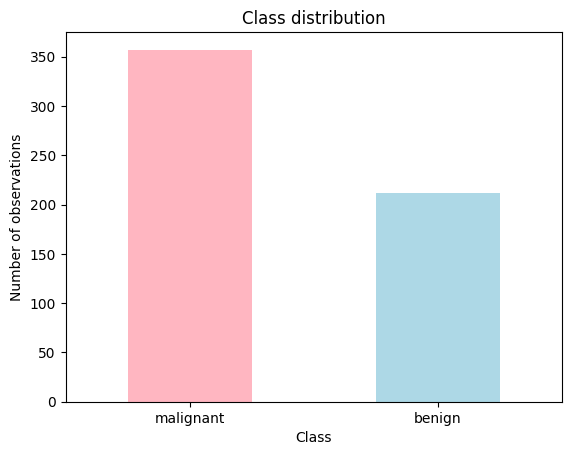

In [ ]:
class_distribution.plot(
    x="Class",
    y="Count",
    kind="bar",
    legend=False,
    color=["lightpink","lightblue"]
)
plt.ylabel("Number of observations")
plt.title("Class distribution")
plt.xticks(rotation=0)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training size:",len(y_train))
print("Testing size:",len(y_test))
print("Training Proportions\n")
print(y_train.value_counts(normalize=True).sort_index())
print(y_test.value_counts(normalize=True).sort_index())

Training size: 455
Testing size: 114
Training Proportions

malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [ ]:
model=make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)
model.fit(x_train,y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [ ]:
probabilities=model.predict_proba(x_test)
print(probabilities[:5])

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]


In [ ]:
print(probabilities[:5].sum(axis=1))

[1. 1. 1. 1. 1.]


In [ ]:
results=pd.DataFrame({
    "Actual_class":y_test.values,
    "P_malignant": probabilities[:,0],
    "P_benign": probabilities[:,1]
})
print(results.head(10))

   Actual_class   P_malignant  P_benign
0             0  9.996354e-01  0.000365
1             1  1.074660e-08  1.000000
2             0  9.574321e-01  0.042568
3             1  4.238127e-01  0.576187
4             0  4.908445e-01  0.509155
5             0  9.993840e-01  0.000616
6             1  2.384659e-01  0.761534
7             0  9.989878e-01  0.001012
8             0  9.994313e-01  0.000569
9             0  9.892324e-01  0.010768


In [ ]:
results["Actual_label"]=results["Actual_class"].map({
    0:"Malignant",
    1:"Benign"
})
print (
    results[["Actual_label","P_malignant","P_benign"]].head(10)
)

  Actual_label   P_malignant  P_benign
0    Malignant  9.996354e-01  0.000365
1       Benign  1.074660e-08  1.000000
2    Malignant  9.574321e-01  0.042568
3       Benign  4.238127e-01  0.576187
4    Malignant  4.908445e-01  0.509155
5    Malignant  9.993840e-01  0.000616
6       Benign  2.384659e-01  0.761534
7    Malignant  9.989878e-01  0.001012
8    Malignant  9.994313e-01  0.000569
9    Malignant  9.892324e-01  0.010768


In [ ]:
threshold=0.50
results["Predicted_malignant"]=(
    results["P_malignant"]>=threshold
).astype(int)
results["Predicted_label"]=results["Predicted_malignant"].map({
    0:"malignant",
    1:"Benign"
})
print(
    results[["Actual_label","P_malignant","Predicted_label"]].head(10))

  Actual_label   P_malignant Predicted_label
0    Malignant  9.996354e-01          Benign
1       Benign  1.074660e-08       malignant
2    Malignant  9.574321e-01          Benign
3       Benign  4.238127e-01       malignant
4    Malignant  4.908445e-01       malignant
5    Malignant  9.993840e-01          Benign
6       Benign  2.384659e-01       malignant
7    Malignant  9.989878e-01          Benign
8    Malignant  9.994313e-01          Benign
9    Malignant  9.892324e-01          Benign


In [ ]:
for threshold in [0.30,0.50,0.70]:
  predictions=(
      results["P_malignant"]>=threshold

  ).astype(int)
  print(f"Threshold={threshold}:"
  f"PRedicted malignant cases={predictions.sum()}")

Threshold=0.3:PRedicted malignant cases=76
Threshold=0.5:PRedicted malignant cases=74
Threshold=0.7:PRedicted malignant cases=72


In [ ]:
actual_malignant=(y_test.values==0).astype(int)
for threshold in [0.30,0.50,0.70]:
  predictions =(probabilities[:,0]>=threshold).astype(int)
  cm=confusion_matrix(actual_malignant,predictions)
  print(f"\nThreshold={threshold}")
  print(cm)


Threshold=0.3
[[38  4]
 [ 0 72]]

Threshold=0.5
[[39  3]
 [ 1 71]]

Threshold=0.7
[[41  1]
 [ 1 71]]


In [ ]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,recall_score,f1_score
)
print("Sklearn accuracy:",
      accuracy_score(y_test,y_pred))


Sklearn accuracy: 0.9649122807017544


In [ ]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

metrics_list = []

for threshold in thresholds:
    predictions = (probabilities[:, 0] >= threshold).astype(int)


    tn, fp, fn, tp = confusion_matrix(actual_malignant, predictions).ravel()


    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    metrics_list.append({
        "Threshold": threshold,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1-Score": f1_score
    })

threshold_metrics_df = pd.DataFrame(metrics_list)
display(threshold_metrics_df.round(3))

,Threshold,TP,TN,FP,FN,Accuracy,Precision,Recall,Specificity,F1-Score
0,0.1,72,33,9,0,0.921,0.889,1.000,0.786,0.941
1,0.3,72,38,4,0,0.965,0.947,1.000,0.905,0.973
2,0.5,71,39,3,1,0.965,0.959,0.986,0.929,0.973
3,0.7,71,41,1,1,0.982,0.986,0.986,0.976,0.986
4,0.9,67,41,1,5,0.947,0.985,0.931,0.976,0.957


In [ ]:
metrics_results=[]
for threshold in [0.1, 0.3, 0.5, 0.7, 0.9]:
  y_pred_threshold=(probabilities[:, 1] >= threshold).astype(int)
  tn, fp, fn, tp = confusion_matrix(y_test,y_pred_threshold,labels=[0,1]).ravel()

  accuracy = (tp + tn) / (tp + tn + fp + fn)
  precision = tp / (tp + fp) if (tp + fp) > 0 else 0
  recall = tp / (tp + fn) if (tp + fn) > 0 else 0
  specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
  f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
  metrics_list.append({
        "Threshold": threshold,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1-Score": f1_score
    })

threshold_metrics_df = pd.DataFrame(metrics_list)
display(threshold_metrics_df.round(3))

,Threshold,TP,TN,FP,FN,Accuracy,Precision,Recall,Specificity,F1-Score
0,0.1,72,33,9,0,0.921,0.889,1.000,0.786,0.941
1,0.3,72,38,4,0,0.965,0.947,1.000,0.905,0.973
2,0.5,71,39,3,1,0.965,0.959,0.986,0.929,0.973
3,0.7,71,41,1,1,0.982,0.986,0.986,0.976,0.986
4,0.9,67,41,1,5,0.947,0.985,0.931,0.976,0.957
5,0.1,41,67,5,1,0.947,0.891,0.976,0.931,0.932
6,0.3,41,71,1,1,0.982,0.976,0.976,0.986,0.976
7,0.5,39,71,1,3,0.965,0.975,0.929,0.986,0.951
8,0.7,38,72,0,4,0.965,1.000,0.905,1.000,0.950
9,0.9,33,72,0,9,0.921,1.000,0.786,1.000,0.880
